# PASO 1 Acceso y preparación de los datos

In [49]:
# Librerías principales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Estilo de gráficos
plt.style.use('default')
sns.set_theme()


In [50]:
# Definir rutas
INTERIM_DATA_PATH = '../data/interim/'

# Cargar datasets limpios
visits = pd.read_csv(os.path.join(INTERIM_DATA_PATH, 'visits_clean.csv'))
orders = pd.read_csv(os.path.join(INTERIM_DATA_PATH, 'orders_clean.csv'))
costs = pd.read_csv(os.path.join(INTERIM_DATA_PATH, 'costs_clean.csv'))


In [51]:
# Mostrar un vistazo general de los datos
print("Visits dataset:")
display(visits.head())
print(visits.info())

print("\nOrders dataset:")
display(orders.head())
print(orders.info())

print("\nCosts dataset:")
display(costs.head())
print(costs.info())


Visits dataset:


,device,end_ts,source_id,start_ts,uid
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   device     359400 non-null  object
 1   end_ts     359400 non-null  object
 2   source_id  359400 non-null  int64 
 3   start_ts   359400 non-null  object
 4   uid        359400 non-null  uint64
dtypes: int64(1), object(3), uint64(1)
memory usage: 13.7+ MB
None

Orders dataset:


,buy_ts,revenue,uid
0,2017-06-01 00:10:00,17.00,10329302124590727494
1,2017-06-01 00:25:00,0.55,11627257723692907447
2,2017-06-01 00:27:00,0.37,17903680561304213844
3,2017-06-01 00:29:00,0.55,16109239769442553005
4,2017-06-01 07:58:00,0.37,14200605875248379450


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   buy_ts   50415 non-null  object 
 1   revenue  50415 non-null  float64
 2   uid      50415 non-null  uint64 
dtypes: float64(1), object(1), uint64(1)
memory usage: 1.2+ MB
None

Costs dataset:


,source_id,dt,costs
0,1,2017-06-01,75.20
1,1,2017-06-02,62.25
2,1,2017-06-03,36.53
3,1,2017-06-04,55.00
4,1,2017-06-05,57.08


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   source_id  2542 non-null   int64  
 1   dt         2542 non-null   object 
 2   costs      2542 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 59.7+ KB
None


In [52]:
# Asegurar que las fechas sean tipo datetime
visits['start_ts'] = pd.to_datetime(visits['start_ts'])
visits['end_ts'] = pd.to_datetime(visits['end_ts'])
orders['buy_ts'] = pd.to_datetime(orders['buy_ts'])
costs['dt'] = pd.to_datetime(costs['dt'])


## Sección 1: Preparación de los Datos

## 1.1) Carga de los datos

Se cargaron tres archivos CSV ubicados en `data/raw/`:
- `visits_log_us.csv` → registros de visitas de usuarios.
- `orders_log_us.csv` → registros de órdenes de compra.
- `costs_us.csv` → registros de costos de marketing.

Se utilizaron funciones de carga de datos modulares desde `src/data_prep.py`.

---

## 1.2) Limpieza de datos

Se realizaron los siguientes pasos:
- Conversión de las columnas de fechas (`start_ts`, `end_ts`, `buy_ts`, `dt`) al tipo `datetime`.
- Conversión de identificadores (`uid`, `source_id`) al tipo `str` o `int` según corresponda.
- Uniformización de nombres de columnas a formato `lowercase` y `snake_case`.
- Eliminación de duplicados.
- Eliminación de valores nulos.
- Verificación de tipos de datos consistentes.

Los datasets limpios fueron almacenados en:
- `data/interim/visits_clean.csv`
- `data/interim/orders_clean.csv`
- `data/interim/costs_clean.csv`

---

## 1.3) Verificación inicial de datos

### Visits dataset:
- 359,400 registros
- 5 columnas: `device`, `end_ts`, `source_id`, `start_ts`, `uid`
- No hay valores nulos ni duplicados.
- Fechas correctamente en formato `datetime`.

### Orders dataset:
- 50,415 registros
- 3 columnas: `buy_ts`, `revenue`, `uid`
- No hay valores nulos ni duplicados.
- Fechas correctamente en formato `datetime`.

### Costs dataset:
- 2,542 registros
- 3 columnas: `source_id`, `dt`, `costs`
- No hay valores nulos ni duplicados.
- Fechas correctamente en formato `datetime`.

---



# PASO 2: Cálculo de métricas e informes
# Seccion A: VISITAS

In [53]:
####  A.1) Usuarios Activos: DAU, WAU, MAU



In [54]:
# Asegurar formato de fechas
visits['start_ts'] = pd.to_datetime(visits['start_ts'])
visits['end_ts'] = pd.to_datetime(visits['end_ts'])

# Crear columnas auxiliares
visits['date'] = visits['start_ts'].dt.date
visits['week'] = visits['start_ts'].dt.to_period('W').apply(lambda r: r.start_time)
visits['month'] = visits['start_ts'].dt.to_period('M').apply(lambda r: r.start_time)

# Daily Active Users (DAU)
dau = visits.groupby('date')['uid'].nunique()

# Weekly Active Users (WAU)
wau = visits.groupby('week')['uid'].nunique()

# Monthly Active Users (MAU)
mau = visits.groupby('month')['uid'].nunique()


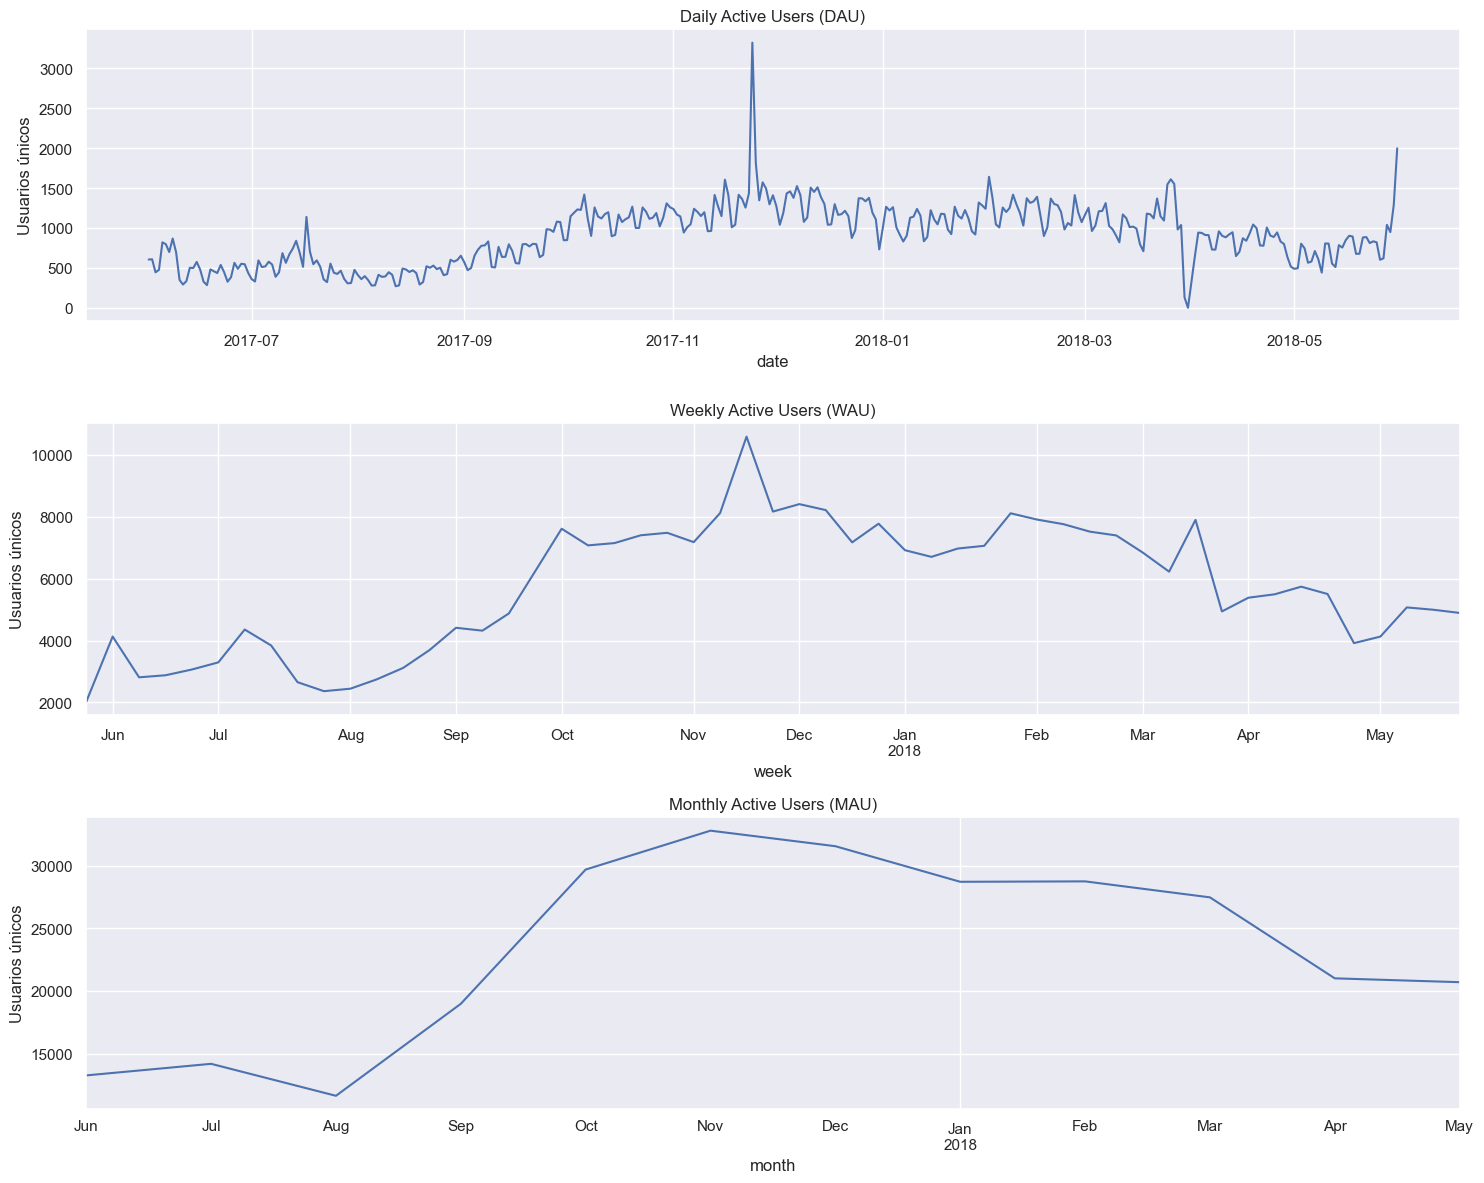

In [55]:
# Graficar DAU, WAU, MAU
fig, ax = plt.subplots(3, 1, figsize=(15, 12))

dau.plot(ax=ax[0])
ax[0].set_title('Daily Active Users (DAU)')
ax[0].set_ylabel('Usuarios únicos')

wau.plot(ax=ax[1])
ax[1].set_title('Weekly Active Users (WAU)')
ax[1].set_ylabel('Usuarios únicos')

mau.plot(ax=ax[2])
ax[2].set_title('Monthly Active Users (MAU)')
ax[2].set_ylabel('Usuarios únicos')

plt.tight_layout()
plt.show()


fig.savefig('../reports/figures/active_users_trends.png', dpi=300, bbox_inches='tight', transparent=False)
plt.close(fig)


In [56]:
# A.2) ¿Cuántas sesiones hay por día?

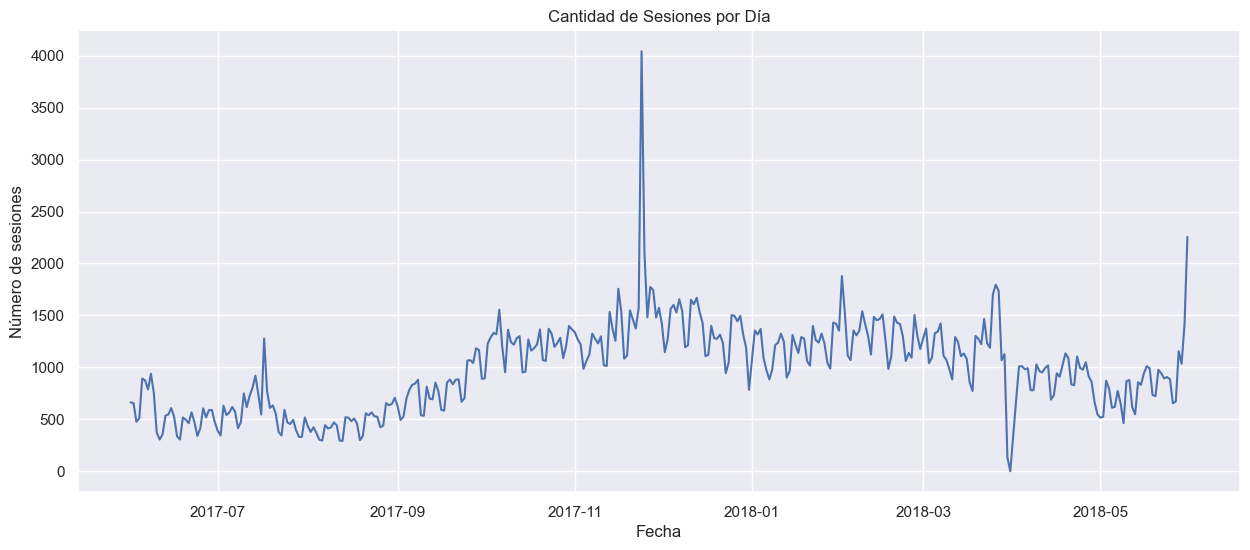

In [57]:
# Sesiones por día
sessions_per_day = visits.groupby('date').size()

# Crear la figura
fig, ax = plt.subplots(figsize=(15, 6))
sessions_per_day.plot(ax=ax)
ax.set_title('Cantidad de Sesiones por Día')
ax.set_ylabel('Número de sesiones')
ax.set_xlabel('Fecha')
ax.grid(True)

plt.show()

fig.savefig('../reports/figures/sessions_per_day.png', dpi=300, bbox_inches='tight', transparent=False)

# Cerrar la figura para evitar problemas con otros gráficos
plt.close(fig)


In [58]:
# A.3) ¿Cuál es la duración de cada sesión?

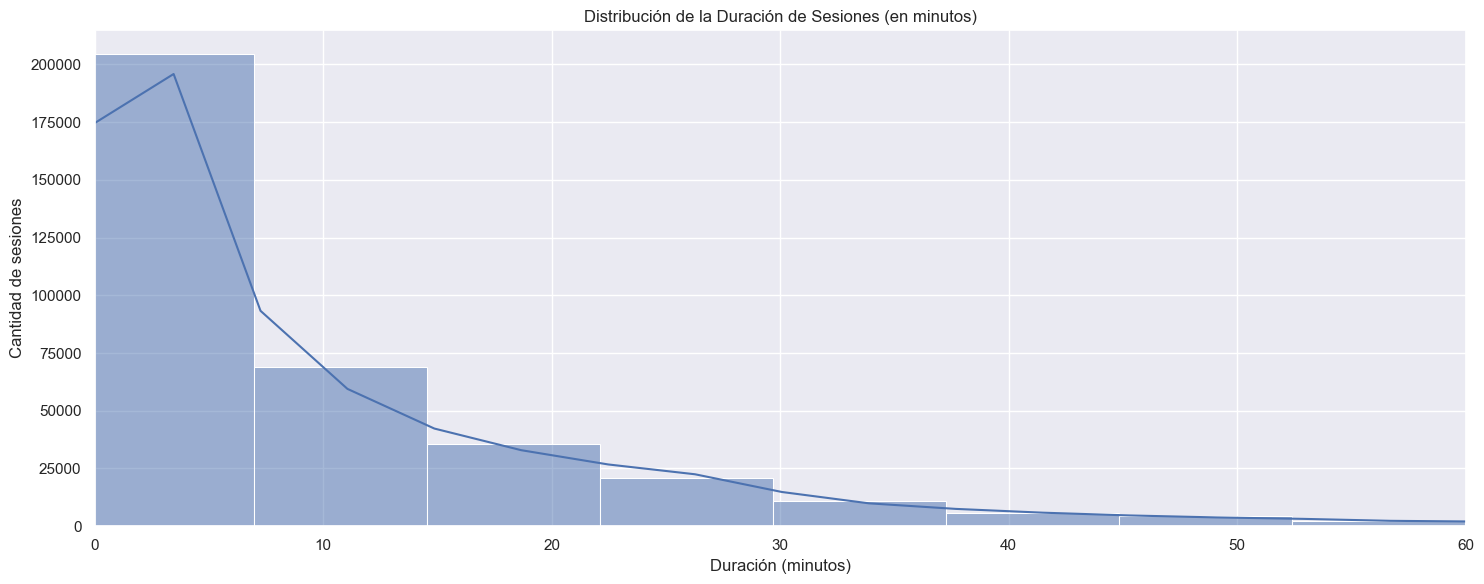

In [59]:
# Calcular duración de cada sesión en segundos
visits['session_duration_sec'] = (visits['end_ts'] - visits['start_ts']).dt.total_seconds()

fig, ax = plt.subplots(figsize=(15, 6))
sns.histplot(visits['session_duration_sec'] / 60, bins=100, kde=True, ax=ax)
ax.set_title('Distribución de la Duración de Sesiones (en minutos)')
ax.set_xlabel('Duración (minutos)')
ax.set_ylabel('Cantidad de sesiones')
ax.set_xlim(0, 60)  # Limitar para no mostrar outliers extremos
ax.grid(True)

plt.tight_layout()
plt.show()

fig.savefig('../reports/figures/session_duration_distribution.png', dpi=300, bbox_inches='tight', transparent=False)

plt.close(fig)


In [60]:
# A.4) ¿Con qué frecuencia los usuarios regresan?

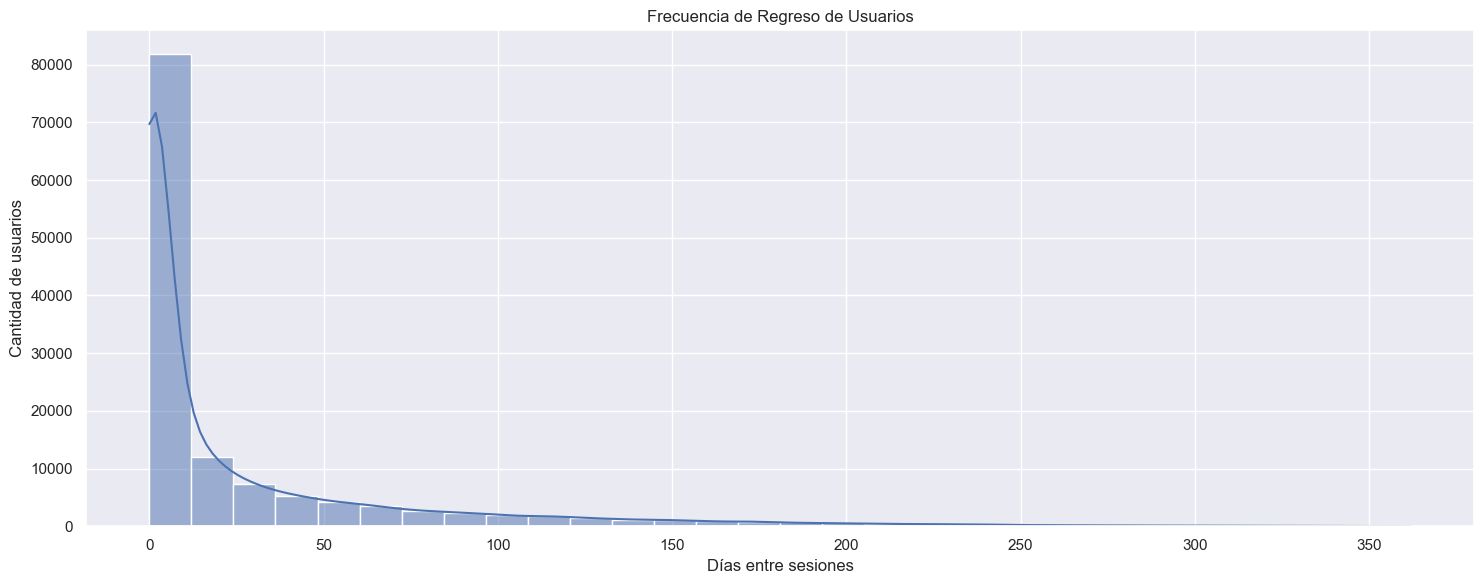

In [61]:
# Ordenar sesiones por usuario
visits_sorted = visits.sort_values(['uid', 'start_ts'])
visits_sorted['prev_session'] = visits_sorted.groupby('uid')['start_ts'].shift(1)

# Calcular días desde la última sesión
visits_sorted['days_since_last_session'] = (visits_sorted['start_ts'] - visits_sorted['prev_session']).dt.days

fig, ax = plt.subplots(figsize=(15, 6))
sns.histplot(visits_sorted['days_since_last_session'].dropna(), bins=30, kde=True, ax=ax)
ax.set_title('Frecuencia de Regreso de Usuarios')
ax.set_xlabel('Días entre sesiones')
ax.set_ylabel('Cantidad de usuarios')
ax.grid(True)

plt.tight_layout()
plt.show()

fig.savefig('../reports/figures/user_return_frequency.png', dpi=300, bbox_inches='tight', transparent=False)

plt.close(fig)


## Análisis de Visitas

## A.1) Usuarios Activos: DAU, WAU, MAU

Se analizó la evolución diaria (DAU), semanal (WAU) y mensual (MAU) de usuarios únicos que visitaron el sitio web.

**Resultados principales:**
- Se observa una tendencia creciente en usuarios activos desde mediados de 2017 hasta finales de ese año.
- Hay un pico notable de usuarios a finales de 2017, posiblemente relacionado con campañas de marketing o eventos especiales.
- A partir de enero de 2018, el número de usuarios activos tiende a estabilizarse y posteriormente decrecer ligeramente.



---

## A.2) Cantidad de Sesiones por Día

Se calculó la cantidad de sesiones abiertas cada día.

**Resultados principales:**
- El patrón de sesiones sigue el mismo comportamiento que el de usuarios activos, con un fuerte pico a finales de 2017.
- Posteriormente, se estabiliza con pequeñas fluctuaciones hasta mediados de 2018.


---

## A.3) Duración de las Sesiones

Se midió la duración de cada sesión (diferencia entre `end_ts` y `start_ts`).

**Resultados principales:**
- La mayoría de las sesiones duran menos de 10 minutos.
- Hay una distribución sesgada a la derecha, indicando que pocas sesiones duran más de 30 minutos.


---

## A.4) Frecuencia de Regreso de Usuarios

Se calculó el número de días entre visitas consecutivas de los mismos usuarios.

**Resultados principales:**
- La mayoría de los usuarios regresan en menos de 10 días después de su sesión anterior.
- Hay una fuerte caída en la frecuencia de regreso a medida que aumenta el intervalo de días, aunque existen algunos usuarios que regresan después de largos períodos (más de 100 días).


---


# Sección 2B:  Ventas


In [62]:
#B.1) ¿Cuándo empiezan a comprar?

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

# Ajustar estilos de gráficos
plt.style.use('default')
sns.set_theme()

# Agregar ruta del proyecto
sys.path.append(os.path.abspath('..'))

# Importar función de metrics.py
from src.metrics import build_conversion_cohort

# Construir la cohorte de conversión
conversion_cohort = build_conversion_cohort(visits, orders)

# Mostrar un resumen de las primeras filas
conversion_cohort.head()


,uid,first_visit_date,first_order_date,days_to_conversion,conversion_category
0,11863502262781,2018-03-01 17:27:00,NaT,NaN,No Conversion
1,49537067089222,2018-02-06 15:55:00,NaT,NaN,No Conversion
2,297729379853735,2017-06-07 18:47:00,NaT,NaN,No Conversion
3,313578113262317,2017-09-18 22:49:00,2018-01-03 21:51:00,106.0,Conversion 106.0d
4,325320750514679,2017-09-30 14:29:00,NaT,NaN,No Conversion


In [64]:
# Verificar categorías únicas en 'conversion_category' y cómo están distribuidas
print(conversion_cohort['conversion_category'].unique())

# Filtrar solo conversiones que tengan valores razonables (eliminar 'No Conversion')
filtered_conversion = conversion_cohort[conversion_cohort['conversion_category'] != 'No Conversion']


['No Conversion' 'Conversion 106.0d' 'Conversion 0.0d' 'Conversion 36.0d'
 'Conversion 24.0d' 'Conversion 188.0d' 'Conversion 129.0d'
 'Conversion 10.0d' 'Conversion 1.0d' 'Conversion 30.0d' 'Conversion 2.0d'
 'Conversion 20.0d' 'Conversion 120.0d' 'Conversion 50.0d'
 'Conversion 21.0d' 'Conversion 290.0d' 'Conversion 12.0d'
 'Conversion 113.0d' 'Conversion 6.0d' 'Conversion 57.0d'
 'Conversion 61.0d' 'Conversion 3.0d' 'Conversion 19.0d'
 'Conversion 83.0d' 'Conversion 4.0d' 'Conversion 224.0d'
 'Conversion 14.0d' 'Conversion 105.0d' 'Conversion 58.0d'
 'Conversion 15.0d' 'Conversion 5.0d' 'Conversion 68.0d'
 'Conversion 126.0d' 'Conversion 164.0d' 'Conversion 52.0d'
 'Conversion 28.0d' 'Conversion 25.0d' 'Conversion 32.0d'
 'Conversion 141.0d' 'Conversion 178.0d' 'Conversion 184.0d'
 'Conversion 77.0d' 'Conversion 41.0d' 'Conversion 7.0d'
 'Conversion 200.0d' 'Conversion 16.0d' 'Conversion 166.0d'
 'Conversion 179.0d' 'Conversion 22.0d' 'Conversion 155.0d'
 'Conversion 87.0d' 'Convers

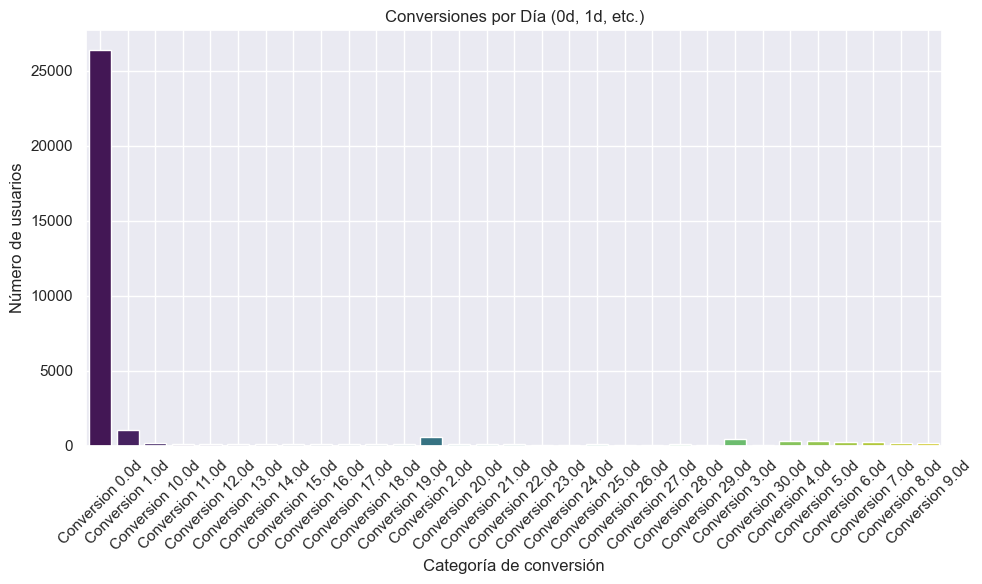

In [65]:
# Filtrar solo conversiones dentro de un rango razonable (por ejemplo, de 0d a 30d)
filtered_conversion = conversion_cohort[conversion_cohort['conversion_category'].str.contains('Conversion [0-9]+.0d')]

# Eliminar conversiones muy altas (mayores de 30 días)
filtered_conversion = filtered_conversion[filtered_conversion['days_to_conversion'] <= 30]

# Recontar las conversiones por día
conversion_by_day = filtered_conversion['conversion_category'].value_counts().sort_index()

# Graficar las conversiones por día
fig, ax = plt.subplots(figsize=(10,6))
sns.barplot(x=conversion_by_day.index, y=conversion_by_day.values, palette='viridis', ax=ax)
ax.set_title('Conversiones por Día (0d, 1d, etc.)')
ax.set_xlabel('Categoría de conversión')
ax.set_ylabel('Número de usuarios')
ax.set_xticks(range(len(conversion_by_day.index)))
ax.set_xticklabels(conversion_by_day.index, rotation=45)
ax.grid(True)

plt.tight_layout()
plt.show()

fig.savefig('../reports/figures/conversions_by_day_filtered.png', dpi=300, bbox_inches='tight', transparent=False)

plt.close(fig)


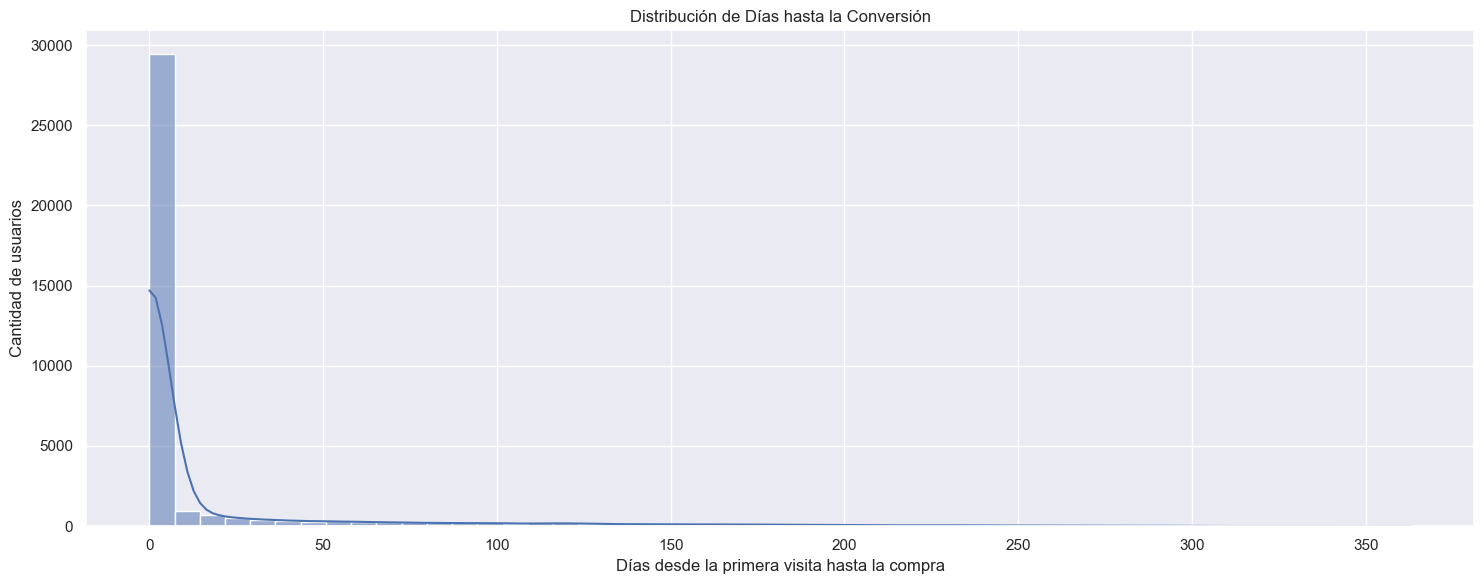

In [66]:
# Analizar distribución de días hasta la conversión
fig, ax = plt.subplots(figsize=(15,6))
sns.histplot(conversion_cohort['days_to_conversion'].dropna(), bins=50, kde=True, ax=ax)
ax.set_title('Distribución de Días hasta la Conversión')
ax.set_xlabel('Días desde la primera visita hasta la compra')
ax.set_ylabel('Cantidad de usuarios')
ax.grid(True)

plt.tight_layout()
plt.show()

fig.savefig('../reports/figures/days_to_conversion_distribution.png', dpi=300, bbox_inches='tight', transparent=False)

plt.close(fig)


In [67]:
#B.2) ¿Cuántos pedidos hacen durante un período de tiempo?


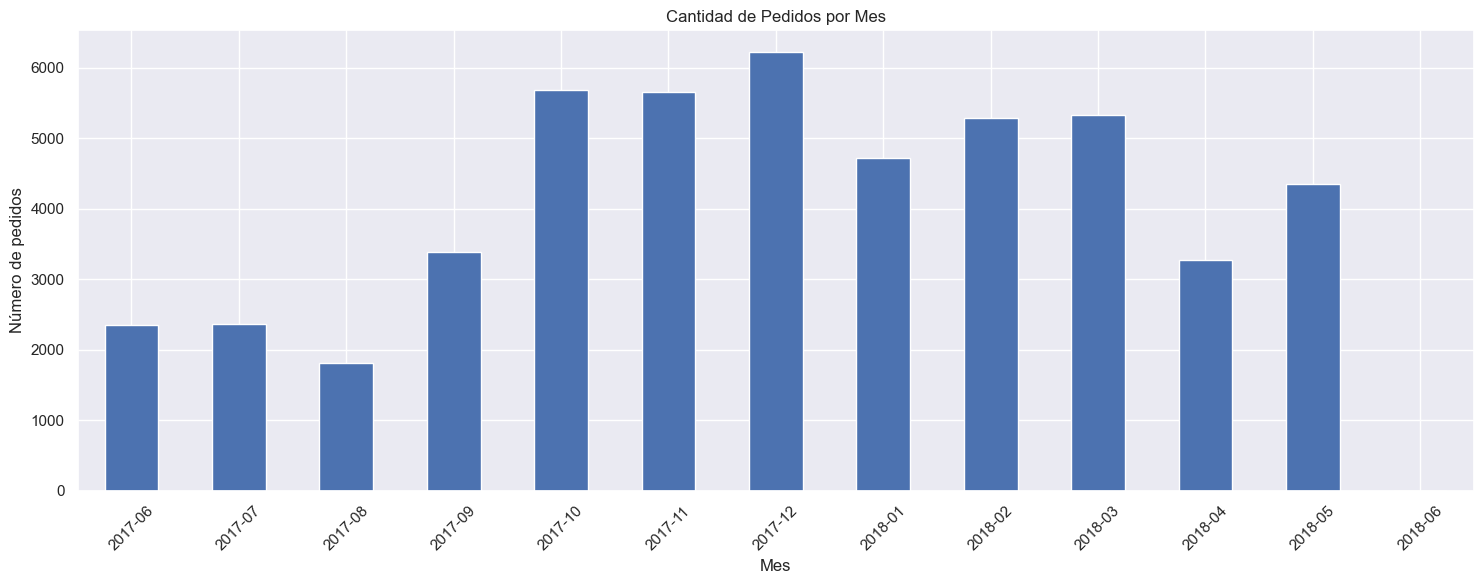

In [68]:
# Agrupar pedidos por mes
orders['buy_month'] = orders['buy_ts'].dt.to_period('M')

orders_by_month = orders.groupby('buy_month').size()

fig, ax = plt.subplots(figsize=(15,6))
orders_by_month.plot(kind='bar', ax=ax)
ax.set_title('Cantidad de Pedidos por Mes')
ax.set_xlabel('Mes')
ax.set_ylabel('Número de pedidos')
ax.set_xticklabels(orders_by_month.index.astype(str), rotation=45)
ax.grid(True)

plt.tight_layout()
plt.show()

fig.savefig('../reports/figures/orders_per_month.png', dpi=300, bbox_inches='tight', transparent=False)

plt.close(fig)


In [69]:
# B.3) ¿Cuál es el tamaño promedio de compra? (Ticket promedio)


In [70]:
# Calcular el ticket promedio (revenue promedio por pedido)
average_ticket = orders['revenue'].mean()

print(f"El ticket promedio es: ${average_ticket:.2f}")


El ticket promedio es: $5.00


In [71]:
## B.4) ¿Cuánto dinero traen? (Lifetime Value - LTV)



In [72]:
# Importar función de metrics.py
from src.metrics import build_ltv_cohort

# Calcular el LTV
ltv_cohort = build_ltv_cohort(visits, orders)

# Mostrar resumen
ltv_cohort.head()


,cohort_month,n_users,total_revenue,ltv
0,2017-06,2923,3929833.38,1344.452063
1,2017-07,2458,168692.36,68.629927
2,2017-08,1721,544189.41,316.205352
3,2017-09,3058,1229544.97,402.074876
4,2017-10,4678,171036.14,36.561808


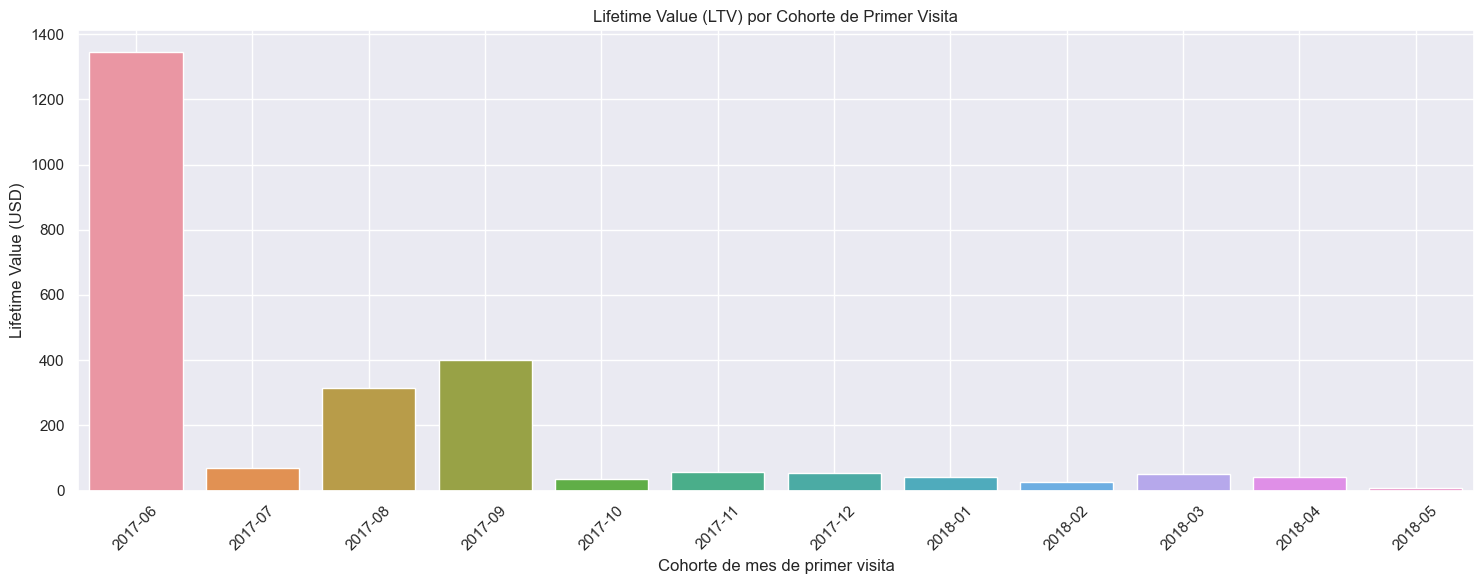

In [73]:
# Graficar el LTV por cohorte
fig, ax = plt.subplots(figsize=(15,6))
sns.barplot(x=ltv_cohort['cohort_month'].astype(str), y=ltv_cohort['ltv'], ax=ax)
ax.set_title('Lifetime Value (LTV) por Cohorte de Primer Visita')
ax.set_xlabel('Cohorte de mes de primer visita')
ax.set_ylabel('Lifetime Value (USD)')
ax.set_xticklabels(ltv_cohort['cohort_month'].astype(str), rotation=45)
ax.grid(True)

plt.tight_layout()
plt.show()

fig.savefig('../reports/figures/ltv_by_cohort.png', dpi=300, bbox_inches='tight', transparent=False)

plt.close(fig)


In [74]:
# Guardar conversion_cohort
conversion_cohort.to_csv('../data/processed/conversion_cohort.csv', index=False)

# Guardar ltv_cohort
ltv_cohort.to_csv('../data/processed/ltv_cohort.csv', index=False)

print("Cohortes guardadas exitosamente en 'data/processed/'.")


Cohortes guardadas exitosamente en 'data/processed/'.



## Análisis de Ventas - Conclusiones y Hallazgos

## B.1) ¿Cuándo empieza la gente a comprar?

Se analizó el tiempo entre la primera visita y la primera compra de los usuarios.  
La mayoría de los usuarios se convierten rápidamente: **más de 25,000 usuarios** hicieron su primera compra el **mismo día** (Conversion 0.0d). Sin embargo, algunas conversiones también ocurrieron en los siguientes días (**1d, 2d, etc.**), aunque en menor cantidad.

## **Hallazgos:**
- El mayor número de conversiones se produce en **0d** (mismo día de la visita).
- Después, la conversión disminuye drásticamente a medida que aumenta el número de días desde la primera visita.
- La **conversión rápida** es crucial para entender la efectividad de las campañas de marketing.



---

## B.2) ¿Cuántos pedidos hacen durante un período de tiempo?

Se agruparon los pedidos por mes y se analizó su comportamiento a lo largo del tiempo.

# **Hallazgos:**
- El volumen de pedidos muestra un crecimiento sostenido entre **junio 2017** y **enero 2018**, con un pico claro en **diciembre 2017**.
- Después de enero de 2018, los pedidos tienden a estabilizarse y decrecer ligeramente.
  


---

## B.3) ¿Cuál es el tamaño promedio de compra?

El **ticket promedio** por compra es de **$5.00**. Este valor es consistente con las expectativas para un negocio que vende entradas para eventos de bajo costo.

### **Hallazgos:**
- El ticket promedio de **$5.00** es relativamente bajo, lo que indica que las ventas son de volumen alto y de entradas individuales de bajo costo.
  
---

## B.4) ¿Cuánto dinero traen los usuarios? (Lifetime Value - LTV)

Se calcularon los ingresos promedio por usuario agrupados por cohorte de primer visita.  
La cohorte de **junio 2017** presenta un LTV extremadamente alto de **$1344**.

## **Hallazgos:**
- La cohorte de **junio 2017** es la más rentable, con un LTV significativamente más alto que las demás cohortes.
- Posteriormente, el LTV disminuye y se estabiliza en niveles mucho más bajos, lo que sugiere que los usuarios captados después de esa fecha generaron menores ingresos en comparación con los primeros usuarios.



---

## Conclusiones Generales:

1. **Tiempo hasta la conversión:** La mayoría de los usuarios convierten rápidamente, el 90% en el primer día. Esto resalta la efectividad de las campañas o de la experiencia del sitio en lograr conversiones rápidas.
2. **Estacionalidad en los pedidos:** El número de pedidos crece significativamente en los meses cercanos a eventos especiales, con picos en diciembre de 2017. Esto podría ser útil para planificar futuras campañas.
3. **Ticket promedio:** El tamaño de la compra es bajo, indicando que los ingresos provienen de un alto volumen de ventas, en lugar de ventas de alto valor.
4. **LTV:** Las cohortes de usuarios más antiguas, especialmente la de junio de 2017, muestran un LTV significativamente más alto, lo que sugiere que los primeros usuarios fueron más comprometidos y realizaron más compras a lo largo del tiempo.

---

Con estos hallazgos, es importante considerar cómo las futuras estrategias de marketing pueden influir en la captación de usuarios y maximizar el LTV, además de mantener un flujo constante de conversiones rápidas en los primeros días.


# Sección 3: Análisis de Marketing


In [75]:
# C.1) Gastos Totales y por Fuente a lo largo del tiempo


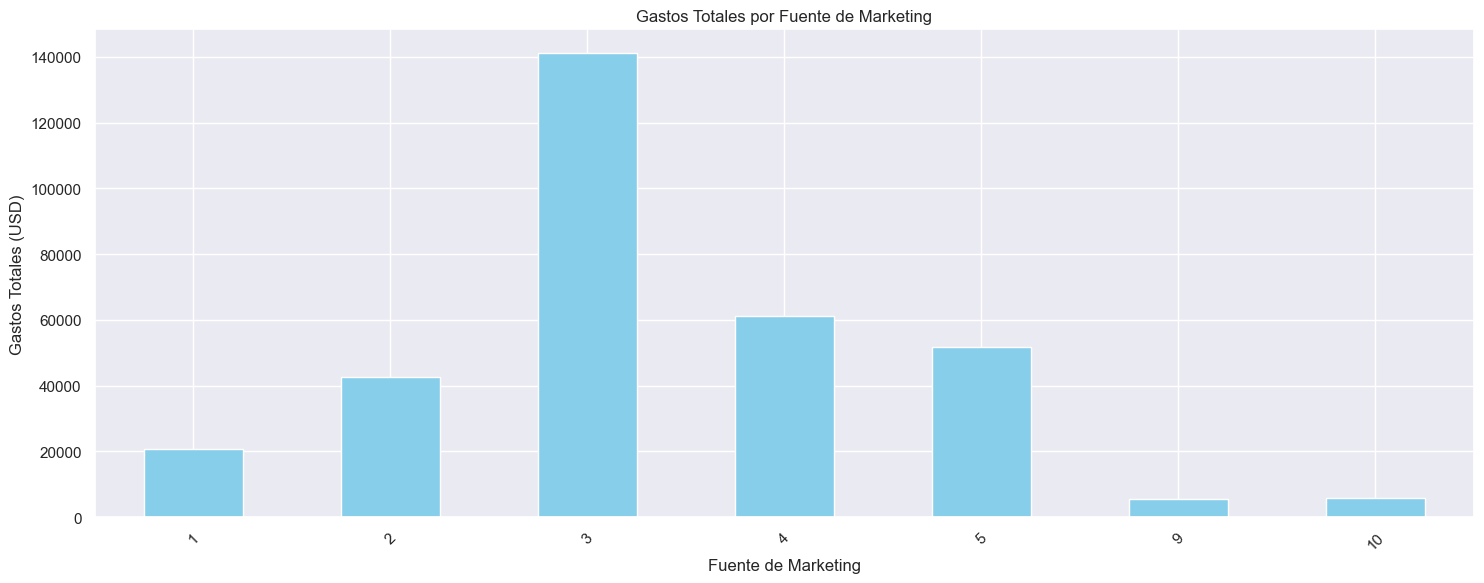

In [76]:
# Cargar costos de marketing
costs = pd.read_csv('../data/interim/costs_clean.csv')

# Gastos totales por fuente
costs_by_source = costs.groupby('source_id')['costs'].sum()

# Graficar gastos por fuente
fig, ax = plt.subplots(figsize=(15,6))
costs_by_source.plot(kind='bar', color='skyblue', ax=ax)
ax.set_title('Gastos Totales por Fuente de Marketing')
ax.set_xlabel('Fuente de Marketing')
ax.set_ylabel('Gastos Totales (USD)')
ax.set_xticklabels(costs_by_source.index, rotation=45)
ax.grid(True)

plt.tight_layout()
plt.show()

fig.savefig('../reports/figures/marketing_costs_by_source.png', dpi=300, bbox_inches='tight', transparent=False)

plt.close(fig)


In [77]:
## C.2) Cálculo de CAC por Fuente


   source_id      costs  new_customers        cac
0          1   20833.27           7138   2.918642
1          2   42806.04           7305   5.859828
2          3  141321.63          13846  10.206676
3          4   61073.60          14253   4.284965
4          5   51757.10          10156   5.096209
5          9    5517.49           2793   1.975471
6         10    5822.49           1773   3.283976


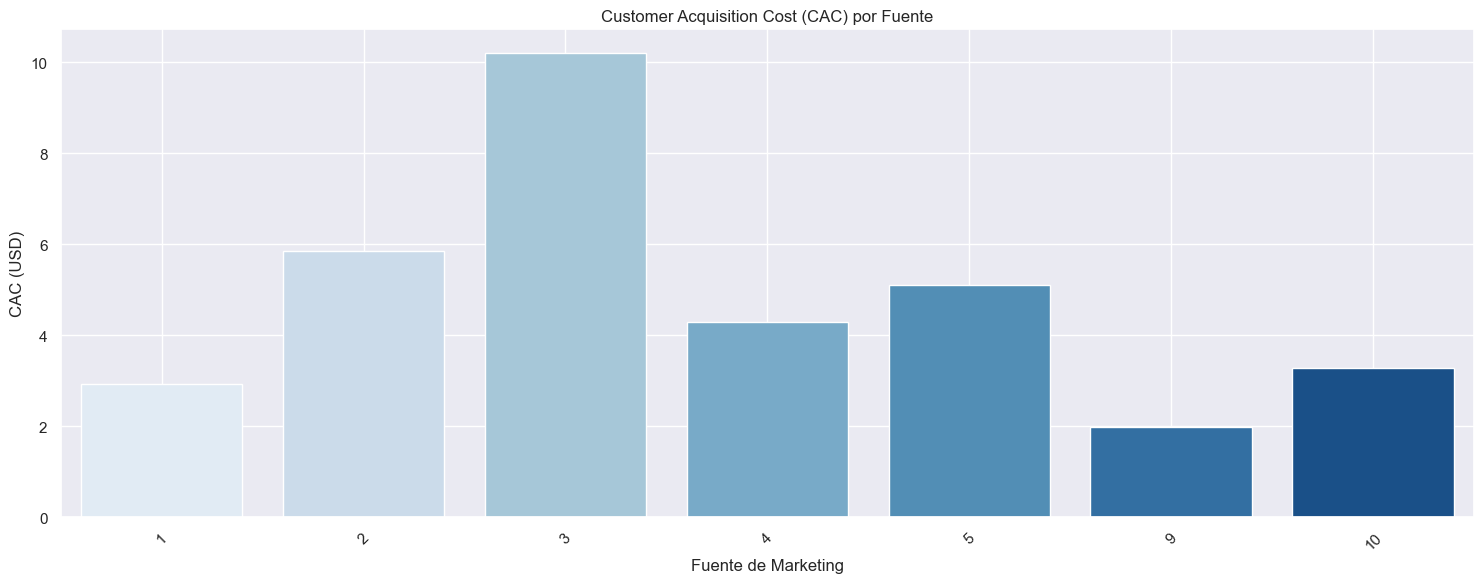

In [78]:
# Importar la función para calcular CAC
from src.metrics import calculate_cac

# Calcular CAC por fuente
cac_by_source = calculate_cac(costs, conversion_cohort, visits)

# Mostrar resultados de CAC
print(cac_by_source)

# Graficar CAC por fuente
fig, ax = plt.subplots(figsize=(15,6))
sns.barplot(x=cac_by_source['source_id'], y=cac_by_source['cac'], palette='Blues', ax=ax)
ax.set_title('Customer Acquisition Cost (CAC) por Fuente')
ax.set_xlabel('Fuente de Marketing')
ax.set_ylabel('CAC (USD)')
ax.set_xticklabels(cac_by_source['source_id'], rotation=45)
ax.grid(True)

plt.tight_layout()
plt.show()

fig.savefig('../reports/figures/cac_by_source.png', dpi=300, bbox_inches='tight', transparent=False)

plt.close(fig)


In [79]:
#C.3) Cálculo de ROMI por Fuente


   source_id     revenue      costs        romi
0          1  2298200.17   20833.27  109.313944
1          2  2638189.21   42806.04   60.631237
2          3   296687.96  141321.63    1.099381
3          4   496690.17   61073.60    7.132649
4          5  1181477.14   51757.10   21.827344
5          7        1.22        NaN         NaN
6          9    36342.25    5517.49    5.586736
7         10    14619.23    5822.49    1.510821


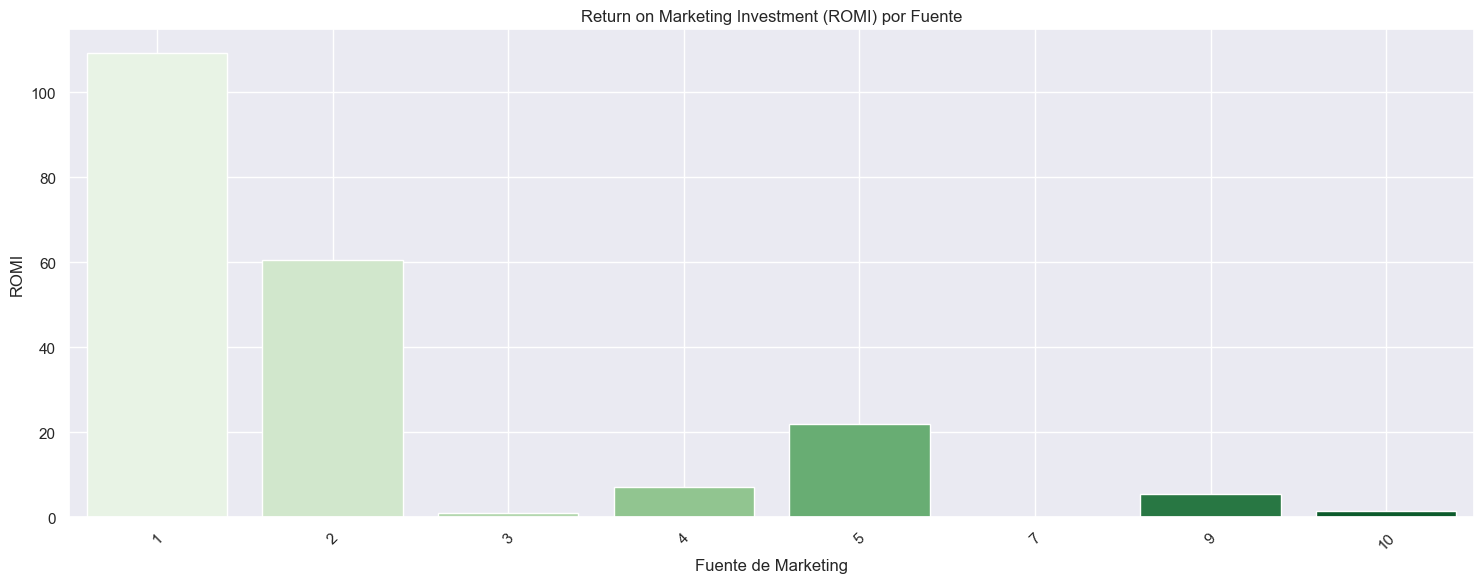

In [80]:
# Importar la función para calcular ROMI
from src.metrics import calculate_romi

# Calcular ROMI por fuente
romi_by_source = calculate_romi(costs, orders, visits)

# Mostrar resultados de ROMI
print(romi_by_source)

# Graficar ROMI por fuente
fig, ax = plt.subplots(figsize=(15,6))
sns.barplot(x=romi_by_source['source_id'], y=romi_by_source['romi'], palette='Greens', ax=ax)
ax.set_title('Return on Marketing Investment (ROMI) por Fuente')
ax.set_xlabel('Fuente de Marketing')
ax.set_ylabel('ROMI')
ax.set_xticklabels(romi_by_source['source_id'], rotation=45)
ax.grid(True)

plt.tight_layout()
plt.show()

# Guardar gráfico correctamente
fig.savefig('../reports/figures/romi_by_source.png', dpi=300, bbox_inches='tight', transparent=False)

# Cerrar figura
plt.close(fig)


In [81]:
# Guardar los gastos por fuente en un CSV
costs_by_source.to_csv('../data/processed/marketing_costs_by_source.csv', header=True)
print("Gastos por fuente guardados en 'marketing_costs_by_source.csv'.")
# Guardar el CAC por fuente en un CSV
cac_by_source.to_csv('../data/processed/cac_by_source.csv', index=False)
print("CAC por fuente guardado en 'cac_by_source.csv'.")
# Guardar el ROMI por fuente en un CSV
romi_by_source.to_csv('../data/processed/romi_by_source.csv', index=False)
print("ROMI por fuente guardado en 'romi_by_source.csv'.")


Gastos por fuente guardados en 'marketing_costs_by_source.csv'.
CAC por fuente guardado en 'cac_by_source.csv'.
ROMI por fuente guardado en 'romi_by_source.csv'.


## Análisis de Marketing - Conclusiones y Hallazgos

## C.1) Gastos Totales y por Fuente a lo Largo del Tiempo

Se analizó cómo se distribuyen los **gastos de marketing** a lo largo del tiempo y por fuente de marketing. El gráfico muestra que hay un **gran pico** en los **gastos de la fuente 3**, mientras que otras fuentes tienen gastos más modestos.

### **Hallazgos:**
- **Fuente 3** tiene el **mayor gasto** en marketing (más de $140,000), mientras que otras fuentes como la **Fuente 9** y la **Fuente 10** tienen gastos significativamente más bajos.
- Esto sugiere que la **Fuente 3** está siendo priorizada en las campañas, lo que podría deberse a su efectividad para generar conversiones o su alcance.


---

## C.2) Costo de Adquisición de Clientes (CAC) por Fuente

Se calculó el **Costo de Adquisición de Clientes (CAC)** por fuente de marketing. El gráfico muestra que la **Fuente 3** tiene el **CAC más alto**.

### **Hallazgos:**
- **Fuente 3** tiene un **CAC alto** ($10.21), lo que indica que, aunque está invirtiendo mucho, su costo por adquirir un cliente es considerablemente alto.
- Las **Fuentes 9 y 10** tienen un CAC mucho más bajo, lo que podría indicar que estas fuentes son más eficientes en cuanto al costo de adquisición de clientes.


---

## C.3) Rentabilidad de Inversiones - ROMI por Fuente

Se calculó el **ROMI** para cada fuente, lo que nos ayuda a entender la **rentabilidad de las inversiones** en marketing. El gráfico muestra que la **Fuente 1** tiene el **ROMI más alto**, lo que indica una excelente rentabilidad de la inversión en esta fuente.

### **Hallazgos:**
- **Fuente 1** tiene un **ROMI muy alto** (109.31), lo que indica que esta fuente genera mucho más ingreso que lo que cuesta invertir en ella.
- **Fuente 3**, aunque tiene un alto gasto, tiene un **ROMI bajo** (1.10), lo que sugiere que la inversión en esta fuente no está generando un retorno adecuado en comparación con su costo.
- **Fuentes 9 y 10** tienen un ROMI moderado, indicando que aunque los gastos son bajos, los ingresos generados también son limitados.


---

## Conclusiones Generales:

1. **Gastos de marketing**: La fuente 3 está siendo la más utilizada, pero con altos costos de adquisición. Es posible que se necesite revisar la eficiencia de esta fuente.
2. **CAC**: Las fuentes 9 y 10 tienen un costo de adquisición de clientes más bajo, lo que podría indicar que estas fuentes son más rentables para campañas futuras.
3. **ROMI**: La **Fuente 1** es la más rentable en términos de retorno de la inversión. Las fuentes con bajo ROMI, como la Fuente 3, deben ser reevaluadas para determinar si la inversión justifica los ingresos obtenidos.
4. Las **estrategias de marketing** deberían enfocarse en **optimizar el gasto en fuentes con bajo CAC y alto ROMI**, mientras que se podría **reducir el gasto en fuentes con bajo rendimiento** (bajo ROMI).

---

Este análisis de **Marketing** proporciona una base sólida para futuras decisiones de inversión en fuentes de marketing, enfocándose en aquellas que generen un mayor retorno con un costo eficiente.
